Bu projede Kaggle Store Sales yarışması kapsamında mağaza, ürün ailesi, promosyon, tarih ve işlem sayısı bilgileri kullanılarak satış tahmini yapılmıştır.

In [4]:
import os

os.listdir("/content")

['.config', 'store-sales-time-series-forecasting.zip', 'sample_data']

In [5]:
#Zip dosyasını çıkarıyoruz.
import zipfile

zip_dosyasi = "/content/store-sales-time-series-forecasting.zip"

with zipfile.ZipFile(zip_dosyasi, "r") as zip_ref:
    zip_ref.extractall("/content/store-sales-time-series-forecasting")

print("Zip başarıyla çıkarıldı.")

Zip başarıyla çıkarıldı.


In [6]:
import os

os.listdir("/content/store-sales-time-series-forecasting")

['test.csv',
 'holidays_events.csv',
 'stores.csv',
 'oil.csv',
 'train.csv',
 'sample_submission.csv',
 'transactions.csv']

In [7]:
#Çalışma dizinini proje klasörüne taşıyoruz.
import os

os.chdir("/content/store-sales-time-series-forecasting")

print(os.getcwd())

/content/store-sales-time-series-forecasting


In [8]:
#Tüm veri setlerini okuyup boyutlarını inceleyelim.

import pandas as pd

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
stores = pd.read_csv("stores.csv")
oil = pd.read_csv("oil.csv")
holidays = pd.read_csv("holidays_events.csv")
transactions = pd.read_csv("transactions.csv")

print("Train:", train.shape)
print("Test:", test.shape)
print("Stores:", stores.shape)
print("Oil:", oil.shape)
print("Holidays:", holidays.shape)
print("Transactions:", transactions.shape)

Train: (3000888, 6)
Test: (28512, 5)
Stores: (54, 5)
Oil: (1218, 2)
Holidays: (350, 6)
Transactions: (83488, 3)


In [9]:
train.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [10]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         object 
 2   store_nbr    int64  
 3   family       object 
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 137.4+ MB


In [11]:
train.isnull().sum()

,0
id,0
date,0
store_nbr,0
family,0
sales,0
onpromotion,0


In [12]:
#Tarih değişkenini datetime formatına çeviriyoruz.
train["date"] = pd.to_datetime(train["date"])
test["date"] = pd.to_datetime(test["date"])

In [13]:
#Verinin kapsadığı tarih aralığını buluyoruz.
print("Başlangıç:", train["date"].min())
print("Bitiş:", train["date"].max())

Başlangıç: 2013-01-01 00:00:00
Bitiş: 2017-08-15 00:00:00


In [14]:
#Kaç mağaza olduğunu öğreniyoruz.
train["store_nbr"].nunique()

54

In [15]:
#Kaç ürün ailesi olduğunu öğreniyoruz.
train["family"].nunique()

33

In [16]:
#Ürün ailelerini görelim.
train["family"].unique()

array(['AUTOMOTIVE', 'BABY CARE', 'BEAUTY', 'BEVERAGES', 'BOOKS',
       'BREAD/BAKERY', 'CELEBRATION', 'CLEANING', 'DAIRY', 'DELI', 'EGGS',
       'FROZEN FOODS', 'GROCERY I', 'GROCERY II', 'HARDWARE',
       'HOME AND KITCHEN I', 'HOME AND KITCHEN II', 'HOME APPLIANCES',
       'HOME CARE', 'LADIESWEAR', 'LAWN AND GARDEN', 'LINGERIE',
       'LIQUOR,WINE,BEER', 'MAGAZINES', 'MEATS', 'PERSONAL CARE',
       'PET SUPPLIES', 'PLAYERS AND ELECTRONICS', 'POULTRY',
       'PREPARED FOODS', 'PRODUCE', 'SCHOOL AND OFFICE SUPPLIES',
       'SEAFOOD'], dtype=object)

In [17]:
#Satış değişkeninin özet istatistikleri.
train["sales"].describe()

,sales
count,3.000888e+06
mean,3.577757e+02
std,1.101998e+03
min,0.000000e+00
25%,0.000000e+00
50%,1.100000e+01
75%,1.958473e+02
max,1.247170e+05


In [18]:
#Promosyon değişkenini inceleyelim.
train["onpromotion"].describe()

,onpromotion
count,3.000888e+06
mean,2.602770e+00
std,1.221888e+01
min,0.000000e+00
25%,0.000000e+00
50%,0.000000e+00
75%,0.000000e+00
max,7.410000e+02


<Axes: xlabel='date'>

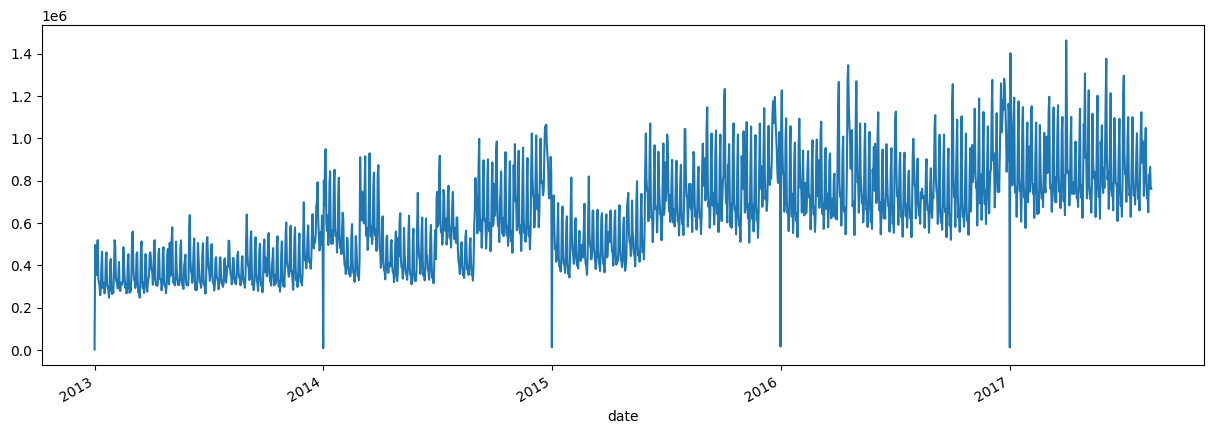

In [19]:
#Toplam günlük satış trendini çıkarıyoruz.
gunluk_satis = train.groupby("date")["sales"].sum()

gunluk_satis.plot(figsize=(15,5))

In [20]:
#Tarih sütununu ayırıyoruz.
train["year"] = train["date"].dt.year
train["month"] = train["date"].dt.month
train["dayofweek"] = train["date"].dt.dayofweek

In [21]:
train.head()

,id,date,store_nbr,family,sales,onpromotion,year,month,dayofweek
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,2013,1,1
1,1,2013-01-01,1,BABY CARE,0.0,0,2013,1,1
2,2,2013-01-01,1,BEAUTY,0.0,0,2013,1,1
3,3,2013-01-01,1,BEVERAGES,0.0,0,2013,1,1
4,4,2013-01-01,1,BOOKS,0.0,0,2013,1,1


<Axes: xlabel='dayofweek'>

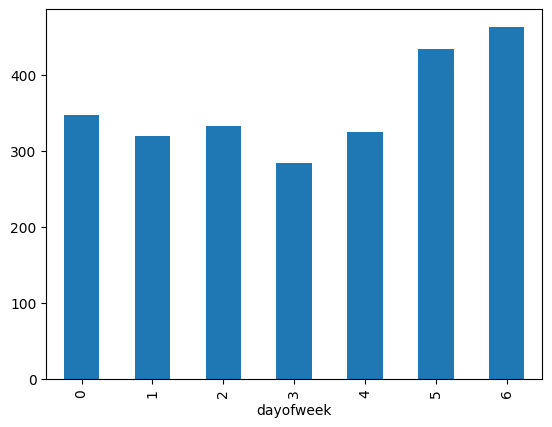

In [22]:
#Haftanın günlerine göre satışlar.
haftalik_satis = train.groupby("dayofweek")["sales"].mean()

haftalik_satis.plot(kind="bar")

<Axes: xlabel='month'>

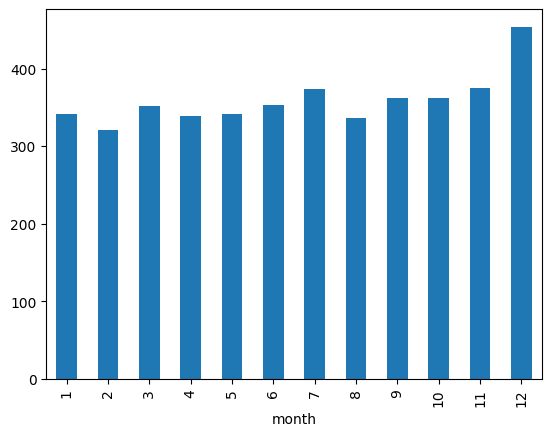

In [23]:
#Aylara göre satışlar.
aylik_satis = train.groupby("month")["sales"].mean()

aylik_satis.plot(kind="bar")

In [24]:
#En çok satan ürün aileleri.
urun_satis = train.groupby("family")["sales"].sum()

urun_satis.sort_values(ascending=False).head(10)

,sales
family,
GROCERY I,3.434627e+08
BEVERAGES,2.169545e+08
PRODUCE,1.227047e+08
CLEANING,9.752129e+07
DAIRY,6.448771e+07
BREAD/BAKERY,4.213395e+07
POULTRY,3.187600e+07
MEATS,3.108647e+07
PERSONAL CARE,2.459205e+07


In [25]:
stores.head()

,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4


In [26]:
stores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   store_nbr  54 non-null     int64 
 1   city       54 non-null     object
 2   state      54 non-null     object
 3   type       54 non-null     object
 4   cluster    54 non-null     int64 
dtypes: int64(2), object(3)
memory usage: 2.2+ KB


In [27]:
oil.head()

,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20


In [28]:
oil.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        1218 non-null   object 
 1   dcoilwtico  1175 non-null   float64
dtypes: float64(1), object(1)
memory usage: 19.2+ KB


In [29]:
holidays.head()

,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False


In [30]:
holidays.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   date         350 non-null    object
 1   type         350 non-null    object
 2   locale       350 non-null    object
 3   locale_name  350 non-null    object
 4   description  350 non-null    object
 5   transferred  350 non-null    bool  
dtypes: bool(1), object(5)
memory usage: 14.1+ KB


In [31]:
transactions.head()

,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922


In [32]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83488 entries, 0 to 83487
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date          83488 non-null  object
 1   store_nbr     83488 non-null  int64 
 2   transactions  83488 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 1.9+ MB


In [33]:
stores.shape

(54, 5)

In [34]:
oil.isnull().sum()

,0
date,0
dcoilwtico,43


In [35]:
holidays["type"].value_counts()

,count
type,
Holiday,221
Event,56
Additional,51
Transfer,12
Bridge,5
Work Day,5


In [36]:
transactions.describe()

,store_nbr,transactions
count,83488.000000,83488.000000
mean,26.939237,1694.602158
std,15.608204,963.286644
min,1.000000,5.000000
25%,13.000000,1046.000000
50%,27.000000,1393.000000
75%,40.000000,2079.000000
max,54.000000,8359.000000


In [37]:
#Promosyon ve satış ilişkisini inceleyelim.
promosyon_satis = train.groupby("onpromotion")["sales"].mean()

promosyon_satis.head(20)

,sales
onpromotion,
0,158.246681
1,467.556532
2,662.925632
3,871.408092
4,969.916135
5,1010.659835
6,1022.854287
7,1022.567058
8,1174.757003


In [38]:
#Promosyonlu ve promosyonsuz kayıt sayıları.
(train["onpromotion"] > 0).value_counts()

,count
onpromotion,
False,2389559
True,611329


In [39]:
#Promosyon etkisini daha net görelim.
train.groupby(train["onpromotion"] > 0)["sales"].mean()

,sales
onpromotion,
False,158.246681
True,1137.693730


In [40]:
#Önce stores tablosunu train ve test ile birleştiriyoruz.
train = train.merge(stores, on="store_nbr", how="left")
test = test.merge(stores, on="store_nbr", how="left")

print(train.shape)
print(test.shape)

(3000888, 13)
(28512, 9)


In [41]:
#Transactions tablosunu birleştiriyoruz.
transactions["date"] = pd.to_datetime(transactions["date"])

train = train.merge(
    transactions,
    on=["date", "store_nbr"],
    how="left"
)

print(train.shape)

(3000888, 14)


In [42]:
train.isnull().sum().sort_values(ascending=False).head(10)

,0
transactions,245784
id,0
store_nbr,0
family,0
sales,0
date,0
onpromotion,0
year,0
dayofweek,0
month,0


In [43]:
#Tarih değişkenlerinden yeni özellikler üretiyoruz.
train["year"] = train["date"].dt.year
train["month"] = train["date"].dt.month
train["day"] = train["date"].dt.day
train["dayofweek"] = train["date"].dt.dayofweek

test["year"] = test["date"].dt.year
test["month"] = test["date"].dt.month
test["day"] = test["date"].dt.day
test["dayofweek"] = test["date"].dt.dayofweek

In [44]:
#Hafta sonu değişkeni oluşturuyoruz.
train["is_weekend"] = train["dayofweek"].isin([5, 6]).astype(int)
test["is_weekend"] = test["dayofweek"].isin([5, 6]).astype(int)

In [45]:
train.head()

,id,date,store_nbr,family,sales,onpromotion,year,month,dayofweek,city,state,type,cluster,transactions,day,is_weekend
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,2013,1,1,Quito,Pichincha,D,13,NaN,1,0
1,1,2013-01-01,1,BABY CARE,0.0,0,2013,1,1,Quito,Pichincha,D,13,NaN,1,0
2,2,2013-01-01,1,BEAUTY,0.0,0,2013,1,1,Quito,Pichincha,D,13,NaN,1,0
3,3,2013-01-01,1,BEVERAGES,0.0,0,2013,1,1,Quito,Pichincha,D,13,NaN,1,0
4,4,2013-01-01,1,BOOKS,0.0,0,2013,1,1,Quito,Pichincha,D,13,NaN,1,0


In [46]:
train.shape

(3000888, 16)

In [47]:
train["transactions"].isnull().mean() * 100

np.float64(8.190375648807953)

In [48]:
#Eksik transaction kayıtlarını görelim.
train[train["transactions"].isnull()].sample(10)

,id,date,store_nbr,family,sales,onpromotion,year,month,dayofweek,city,state,type,cluster,transactions,day,is_weekend
1418932,1418932,2015-03-10,21,SCHOOL AND OFFICE SUPPLIES,0.0,0,2015,3,1,Santo Domingo,Santo Domingo de los Tsachilas,B,6,NaN,10,0
1826350,1826350,2015-10-24,52,SCHOOL AND OFFICE SUPPLIES,0.0,0,2015,10,5,Manta,Manabi,A,11,NaN,24,1
1014364,1014364,2014-07-25,20,EGGS,0.0,0,2014,7,4,Quito,Pichincha,B,6,NaN,25,0
431957,431957,2013-08-31,29,LAWN AND GARDEN,0.0,0,2013,8,5,Guayaquil,Guayas,E,10,NaN,31,1
1427841,1427841,2015-03-15,21,PRODUCE,0.0,0,2015,3,6,Santo Domingo,Santo Domingo de los Tsachilas,B,6,NaN,15,1
987648,987648,2014-07-10,20,MEATS,0.0,0,2014,7,3,Quito,Pichincha,B,6,NaN,10,0
895769,895769,2014-05-19,42,HOME APPLIANCES,0.0,0,2014,5,0,Cuenca,Azuay,D,2,NaN,19,0
703711,703711,2014-01-31,53,LADIESWEAR,0.0,0,2014,1,4,Manta,Manabi,D,13,NaN,31,0
63075,63075,2013-02-05,29,GROCERY I,0.0,0,2013,2,1,Guayaquil,Guayas,E,10,NaN,5,0
308733,308733,2013-06-23,21,HOME CARE,0.0,0,2013,6,6,Santo Domingo,Santo Domingo de los Tsachilas,B,6,NaN,23,1


In [49]:
#Transactions ile satış ilişkisi.
train[["transactions","sales"]].corr()

,transactions,sales
transactions,1.000000,0.214815
sales,0.214815,1.000000


In [50]:
#Transactions eksiklerini mağaza bazlı medyan ile dolduruyoruz.
train["transactions"] = train["transactions"].fillna(
    train.groupby("store_nbr")["transactions"].transform("median")
)

In [51]:
train["transactions"].isnull().sum()

np.int64(0)

In [52]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 16 columns):
 #   Column        Dtype         
---  ------        -----         
 0   id            int64         
 1   date          datetime64[ns]
 2   store_nbr     int64         
 3   family        object        
 4   sales         float64       
 5   onpromotion   int64         
 6   year          int32         
 7   month         int32         
 8   dayofweek     int32         
 9   city          object        
 10  state         object        
 11  type          object        
 12  cluster       int64         
 13  transactions  float64       
 14  day           int32         
 15  is_weekend    int64         
dtypes: datetime64[ns](1), float64(2), int32(4), int64(5), object(4)
memory usage: 320.5+ MB


In [53]:
#Kategorik değişkenleri sayısala çeviriyoruz.
from sklearn.preprocessing import LabelEncoder

family_encoder = LabelEncoder()
city_encoder = LabelEncoder()
state_encoder = LabelEncoder()
type_encoder = LabelEncoder()

train["family"] = family_encoder.fit_transform(train["family"])
test["family"] = family_encoder.transform(test["family"])

train["city"] = city_encoder.fit_transform(train["city"])
test["city"] = city_encoder.transform(test["city"])

train["state"] = state_encoder.fit_transform(train["state"])
test["state"] = state_encoder.transform(test["state"])

train["type"] = type_encoder.fit_transform(train["type"])
test["type"] = type_encoder.transform(test["type"])

In [54]:
#Modelde kullanacağımız sütunları seçiyoruz.
train.shape

(3000888, 16)

In [55]:
#İlk modeli veri örneklemi üzerinde eğitiyoruz.
train_sample = train.sample(
    n=300000,
    random_state=42
)

In [56]:
# Bağımlı ve bağımsız değişkenlerimizi oluşturuyoruz.
x = train_sample.drop(columns=["id", "date", "sales"])
y = train_sample["sales"]

x_test = test.drop(columns=["id", "date"])

In [57]:
from sklearn.model_selection import train_test_split

x_train, x_valid, y_train, y_valid = train_test_split(x, y, test_size=0.20, random_state=42)

In [58]:
#İlk modelimizi kuruyoruz.
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

model.fit(x_train, y_train)

RandomForestRegressor(n_estimators=50, n_jobs=-1, random_state=42)

In [59]:
#Tahmin yapıyoruz.
from sklearn.metrics import mean_absolute_error, r2_score

pred = model.predict(x_valid)

print("MAE:", mean_absolute_error(y_valid, pred))
print("R2:", r2_score(y_valid, pred))

MAE: 60.094470033598306
R2: 0.930371023921327


In [60]:
#Gradient Boosting modelini kuruyoruz.
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gb_model.fit(x_train, y_train)

GradientBoostingRegressor(random_state=42)

In [61]:
gb_pred = gb_model.predict(x_valid)

In [62]:
from sklearn.metrics import mean_absolute_error, r2_score

print("MAE:", mean_absolute_error(y_valid, gb_pred))
print("R2:", r2_score(y_valid, gb_pred))

MAE: 191.59395003241733
R2: 0.779718055433647


In [63]:
#İki modeli tablo halinde karşılaştırıyoruz.
import pandas as pd

sonuclar = pd.DataFrame({
    "Model": ["Random Forest", "Gradient Boosting"],
    "MAE": [
        mean_absolute_error(y_valid, pred),
        mean_absolute_error(y_valid, gb_pred)
    ],
    "R2": [
        r2_score(y_valid, pred),
        r2_score(y_valid, gb_pred)
    ]
})

sonuclar

,Model,MAE,R2
0,Random Forest,60.09447,0.930371
1,Gradient Boosting,191.59395,0.779718


In [64]:
#Test verisine transactions sütunu ekliyoruz.
store_transaction_median = train.groupby("store_nbr")["transactions"].median()

test["transactions"] = test["store_nbr"].map(store_transaction_median)
test["transactions"] = test["transactions"].fillna(train["transactions"].median())

In [65]:
#Train ve test sütunlarını aynı sıraya getiriyoruz.
x_test = test.drop(columns=["id", "date"])

x_test = x_test[x_train.columns]

In [66]:
#Submission tahminini alıyoruz.
test_pred = model.predict(x_test)

test_pred = test_pred.clip(min=0)

In [67]:
submission = pd.read_csv("sample_submission.csv")
submission["sales"] = test_pred
submission.to_csv("submission.csv", index=False)

submission.head()

,id,sales
0,3000888,6.12
1,3000889,0.00
2,3000890,7.74
3,3000891,2455.60
4,3000892,0.34


In [68]:
#Model, kullanılan kolonlar ve encoder’ları kaydediyoruz.
import joblib

model_bilgileri = {
    "model": model,
    "columns": list(x.columns),
    "family_encoder": family_encoder,
    "city_encoder": city_encoder,
    "state_encoder": state_encoder,
    "type_encoder": type_encoder,
    "store_transaction_median": store_transaction_median
}

joblib.dump(model_bilgileri, "store_sales_model.pkl",  compress=3)

['store_sales_model.pkl']

Bu projede Kaggle’ın Store Sales - Time Series Forecasting veri seti kullanılarak mağaza satış tahmini yapılmıştır. Veri hazırlama aşamasında satış verileri mağaza ve işlem sayısı bilgileriyle birleştirilmiş; tarih değişkeninden yıl, ay, gün, haftanın günü ve hafta sonu gibi yeni özellikler üretilmiştir. Modelleme aşamasında Random Forest ve Gradient Boosting algoritmaları karşılaştırılmıştır. Karşılaştırma sonucunda Random Forest modeli MAE ≈ 60.09 ve R² ≈ 0.9304 değeriyle daha başarılı sonuç vermiştir. Bu nedenle final tahminlerde Random Forest modeli kullanılmış ve Kaggle submission dosyası oluşturularak 0.69777 public score elde edilmiştir.